In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
df_emb = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/closest_embedding/norman_results_all.csv", index_col=0)
df_emb["condition"] = df_emb.index

In [3]:
df_emb.head()

,encoded_ood_r_squared,encoded_ood_e_distance,encoded_ood_mmd,condition,decoded_ood_r_squared,decoded_ood_e_distance,decoded_ood_mmd,deg_ood_r_squared,deg_ood_e_distance,deg_ood_mmd,subgroup,model
AHR+KLF1,-2.908048,74.546690,0.098292,AHR+KLF1,0.927090,126.558290,0.026295,0.736697,29.262020,0.068725,double_seen_1,closest_embedding
ARID1A+ctrl,-0.856666,26.093662,0.049275,ARID1A+ctrl,0.965542,52.679382,0.016020,0.888779,17.823984,0.056391,single,closest_embedding
BCL2L11+BAK1,0.958315,0.396355,0.006472,BCL2L11+BAK1,0.997289,4.510895,0.008751,0.322746,0.454313,0.070497,double_seen_1,closest_embedding
BCL2L11+TGFBR2,-0.447892,11.815022,0.027509,BCL2L11+TGFBR2,0.987476,20.501587,0.011079,0.935022,3.875095,0.022406,double_seen_1,closest_embedding
BCL2L11+ctrl,-3.978752,32.543130,0.054624,BCL2L11+ctrl,0.972371,45.407320,0.015237,0.979700,0.401801,0.035993,single,closest_embedding


In [4]:
scgpt_dir = "/lustre/groups/ml01/workspace/leander.dony/projects/cellflow/250302_scGPT/metrics/"

In [5]:


split_to_splitname = {"comboseen0": "double_seen_0", "comboseen1": "double_seen_1", "comboseen2": "double_seen_2", "unseensingle": "single"}
splits = split_to_splitname.keys()
seeds = np.arange(1,6)

dfs = []
for split in splits:
    for seed in seeds:
        file = f"metrics_scgpt_seed{seed}_{split}.csv"
        df = pd.read_csv(os.path.join(scgpt_dir, file), index_col=0)
        df = df.drop("mean")
        df["condition"] = df.index
        df["subgroup"] = split_to_splitname[split]
        df["seed"] = seed
        df["model"] = "scgpt"
        dfs.append(df)


In [6]:
df_scgpt = pd.concat(dfs)

In [7]:
res = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/results/allocation/results_norman_prelim2.csv", index_col=0)

In [8]:
res.head()

,subgroup,condition,encoded_ood_r_squared,encoded_ood_sinkhorn_div_1,encoded_ood_sinkhorn_div_10,encoded_ood_sinkhorn_div_100,encoded_ood_e_distance,encoded_ood_mmd,decoded_ood_r_squared,decoded_ood_e_distance,...,deg_ood_sinkhorn_div_1,deg_ood_sinkhorn_div_10,deg_ood_sinkhorn_div_100,deg_ood_e_distance,deg_ood_mmd,seed,model,decoded_ood_sinkhorn_div_1,decoded_ood_sinkhorn_div_10,decoded_ood_sinkhorn_div_100
0,double_seen_1,AHR+KLF1,-0.235969,26.363504,20.453796,13.004532,23.576266,0.088512,0.965454,59.965783,...,49.004730,23.053215,9.580486,18.465538,0.055382,1,biolord,NaN,NaN,NaN
1,single,ARID1A+ctrl,-0.870820,32.711014,26.043972,15.835747,26.292580,0.075837,0.957185,65.454483,...,51.148735,24.314388,9.643890,18.312755,0.052491,1,biolord,NaN,NaN,NaN
2,double_seen_1,BCL2L11+BAK1,0.912641,8.554052,2.861893,0.661819,0.830657,0.019190,0.984661,25.525600,...,40.841179,14.373302,0.673000,0.470072,0.452304,1,biolord,NaN,NaN,NaN
3,double_seen_1,BCL2L11+TGFBR2,0.863316,9.772830,4.568264,0.941708,1.115361,0.019349,0.985263,24.123491,...,38.525169,14.326378,1.011749,1.303958,0.060637,1,biolord,NaN,NaN,NaN
4,single,BCL2L11+ctrl,0.888504,9.687116,4.609301,0.755690,0.728787,0.016104,0.986481,22.218412,...,39.652954,13.896275,0.832378,0.833630,0.280454,1,biolord,NaN,NaN,NaN


In [9]:
df_all = pd.concat((res, df_scgpt, df_emb))

In [10]:
df_all.shape

(3430, 22)

In [11]:
import seaborn as sns

<Axes: xlabel='model', ylabel='decoded_ood_r_squared'>

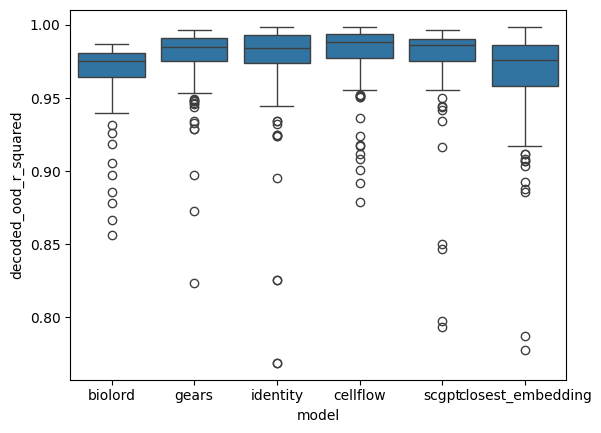

In [12]:
sns.boxplot(df_all[df_all["subgroup"]=="single"], x="model", y="decoded_ood_r_squared")

<Axes: xlabel='model', ylabel='encoded_ood_e_distance'>

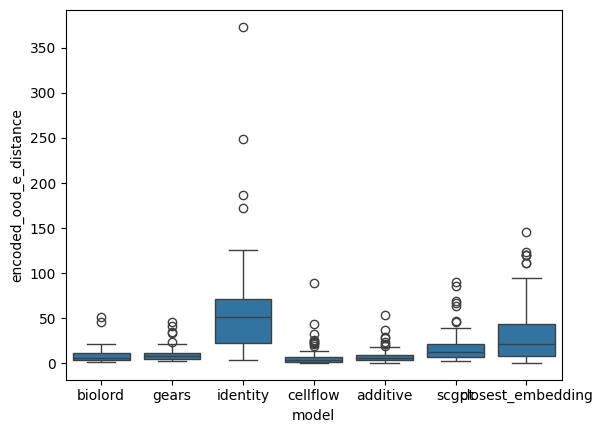

In [13]:
sns.boxplot(df_all[df_all["subgroup"]=="double_seen_2"], x="model", y="encoded_ood_e_distance")

In [14]:
df_all["model"].value_counts()

model
biolord              561
gears                561
identity             561
cellflow             561
scgpt                561
closest_embedding    561
additive              64
Name: count, dtype: int64

In [15]:
df_all.to_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/results/allocation/norman_results_all.csv")